In [88]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Load your dataset
df = pd.read_excel('/Users/shubhamjha/Desktop/coding/ML/pythonforML/minor/Students_Performance_data_set.xlsx')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1194, 31)
Total Records: 1194
Total Features: 31

First 5 rows:


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [46]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\n✅ Missing values handled!")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed!")

Missing Values:
University Admission year                                                    0
Gender                                                                       0
Age                                                                          0
H.S.C passing year                                                           0
Program                                                                      0
Current Semester                                                             0
Do you have meritorious scholarship ?                                        0
Do you use University transportation?                                        0
How many hour do you study daily?                                            0
How many times do you seat for study in a day?                               0
What is your preferable learning mode?                                       0
Do you use smart phone?                                                      0
Do you have personal Computer?      

In [47]:
df["What is your current CGPA?"]

0       3.15
1       3.15
2       3.15
3       3.15
4       3.15
        ... 
1189    3.77
1190    2.22
1191    2.78
1192    2.52
1193    2.88
Name: What is your current CGPA?, Length: 1194, dtype: float64

In [48]:
df["What was your previous SGPA?"]

0       2.68
1       2.68
2       2.68
3       2.68
4       2.68
        ... 
1189    2.65
1190    2.50
1191    1.56
1192    1.40
1193    1.34
Name: What was your previous SGPA?, Length: 1194, dtype: float64

In [49]:
# Identify CGPA column

cgpa_col = [c for c in df.columns if "CGPA" in c or "SGPA" in c]
if len(cgpa_col) == 0:
    raise ValueError("No CGPA column found!")

print("CGPA Column:", cgpa_col)

CGPA Column: ['What was your previous SGPA?', 'What is your current CGPA?']


In [50]:
df[cgpa_col[1]]

0       3.15
1       3.15
2       3.15
3       3.15
4       3.15
        ... 
1189    3.77
1190    2.22
1191    2.78
1192    2.52
1193    2.88
Name: What is your current CGPA?, Length: 1194, dtype: float64

In [51]:
# CGPA SCALING

for col in cgpa_col:
    # Clip values to 0–10
    df[col] = df[col].clip(lower=0, upper=10)

    # If values are in 0–4 scale, convert to 0–10
    if df[col].max() <= 4:
        df[col] = df[col] * 2.5

print("\nFinal CGPA/SGPA ranges:")
for col in cgpa_col:
    print(col, ":", df[col].min(), "to", df[col].max())


Final CGPA/SGPA ranges:
What was your previous SGPA? : 0.0 to 10.0
What is your current CGPA? : 0.0 to 10.0


In [52]:
df[cgpa_col[1]]

0       7.875
1       7.875
2       7.875
3       7.875
4       7.875
        ...  
1189    9.425
1190    5.550
1191    6.950
1192    6.300
1193    7.200
Name: What is your current CGPA?, Length: 1194, dtype: float64

In [53]:
df[cgpa_col[0]]

0       6.700
1       6.700
2       6.700
3       6.700
4       6.700
        ...  
1189    6.625
1190    6.250
1191    3.900
1192    3.500
1193    3.350
Name: What was your previous SGPA?, Length: 1194, dtype: float64

In [54]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

# Encode categorical variables
df_encoded = df.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print(f"\n✅ Encoded {len(categorical_cols)} categorical columns!")

Categorical columns: 19


Numerical columns: 12

✅ Encoded 19 categorical columns!


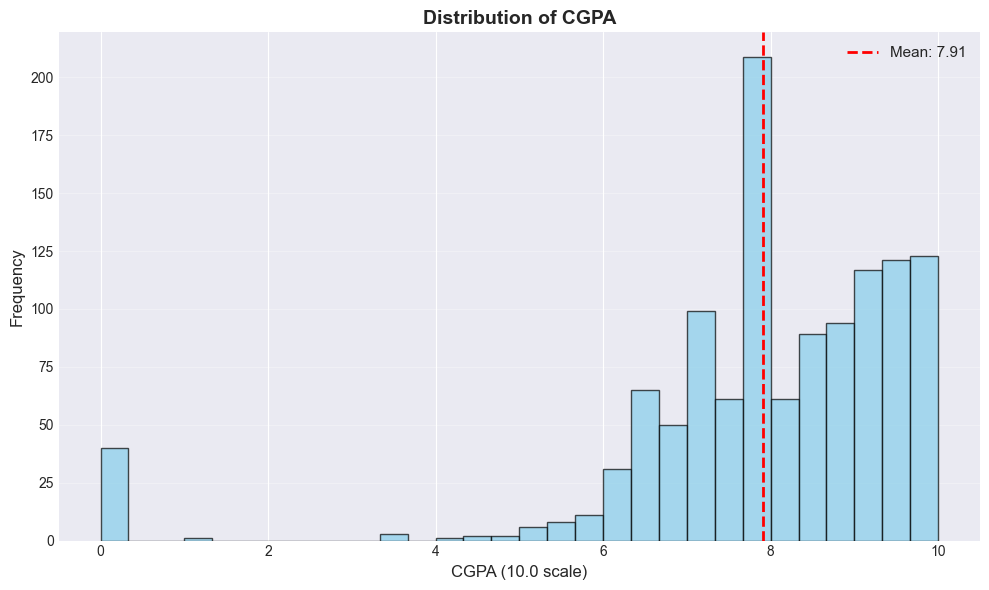

Mean CGPA: 7.91
Median CGPA: 8.03
Std Dev: 1.88


In [55]:
plt.figure(figsize=(10, 6))
plt.hist(df_encoded[cgpa_col[1]], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('CGPA (10.0 scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of CGPA', fontsize=14, fontweight='bold')
plt.axvline(df_encoded[cgpa_col[1]].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_encoded[cgpa_col[1]].mean():.2f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean CGPA: {df_encoded[cgpa_col[1]].mean():.2f}")
print(f"Median CGPA: {df_encoded[cgpa_col[1]].median():.2f}")
print(f"Std Dev: {df_encoded[cgpa_col[1]].std():.2f}")

In [56]:
# Comprehensive Feature Dependency Visualization on CGPA

print("VISUALIZING FEATURE DEPENDENCY ON CGPA")

TARGET_COLUMN = "What is your current CGPA?"
# Get all features except the target
features = [col for col in df_encoded.columns if col != TARGET_COLUMN]
numerical_features = df_encoded[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_encoded[features].select_dtypes(include=['object']).columns.tolist()

print(f"\nTotal Features: {len(features)}")
print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

VISUALIZING FEATURE DEPENDENCY ON CGPA

Total Features: 30
Numerical Features: 30
Categorical Features: 0


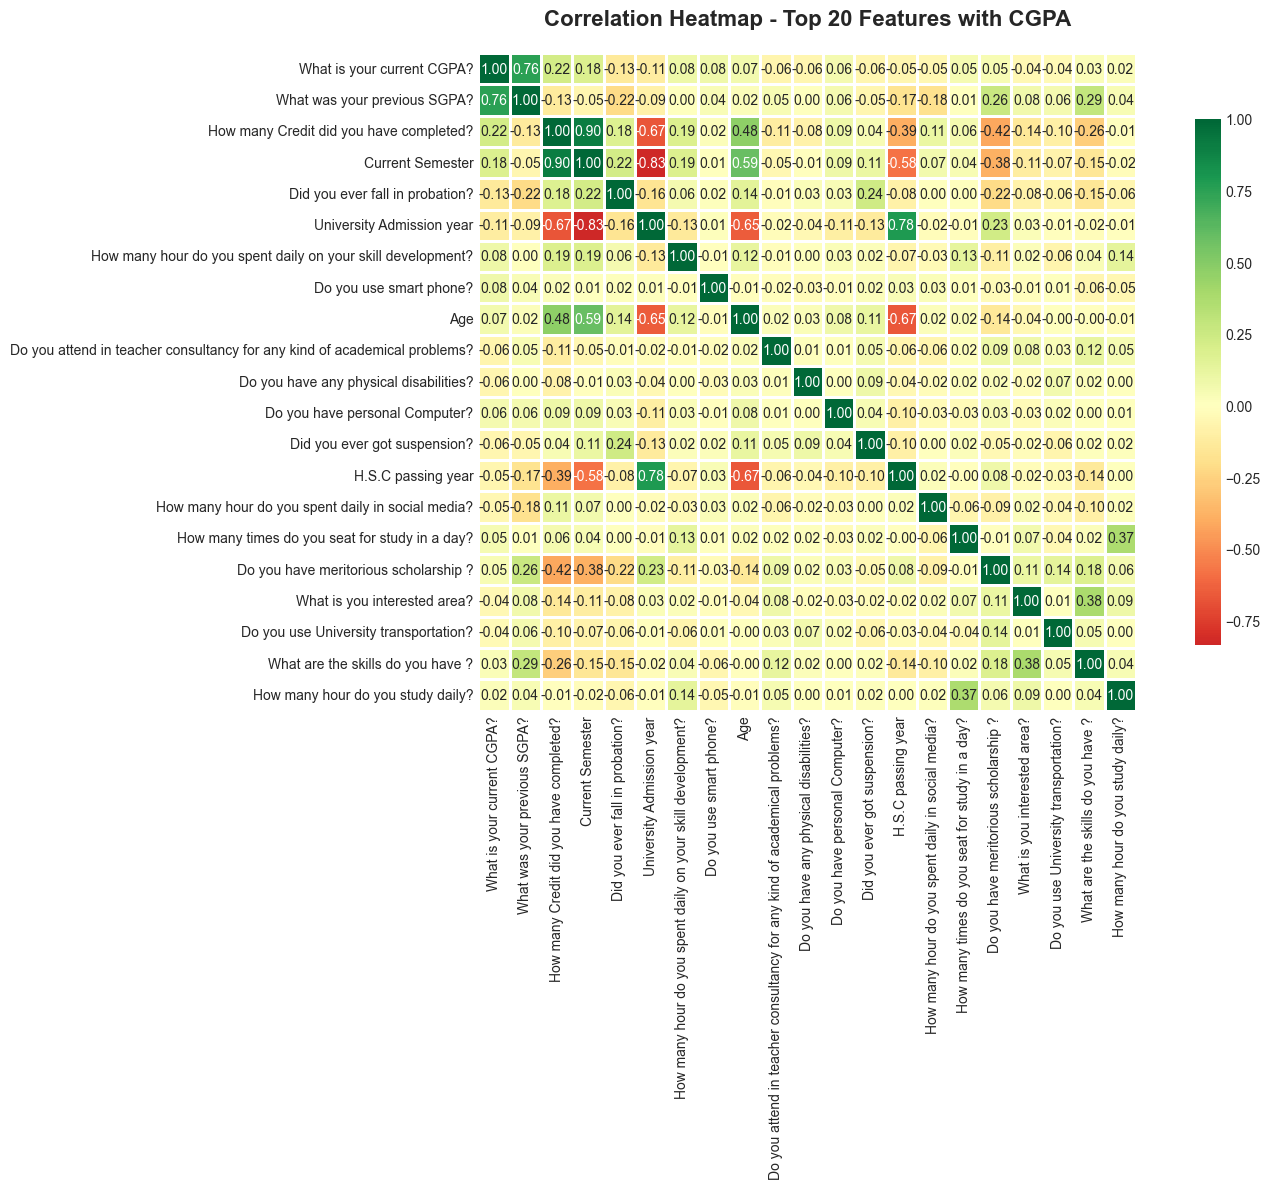

✅ Correlation Heatmap Created


In [57]:
# Create correlation matrix for all numerical features
plt.figure(figsize=(16, 12))

# Select top 20 most correlated features with CGPA
correlations_all = df_encoded[numerical_features + [TARGET_COLUMN]].corr()[TARGET_COLUMN].abs().sort_values(ascending=False)
top_20_features = correlations_all.head(21).index.tolist()  # 21 including CGPA itself

# Create correlation matrix for top features
corr_matrix = df_encoded[top_20_features].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 20 Features with CGPA', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✅ Correlation Heatmap Created")

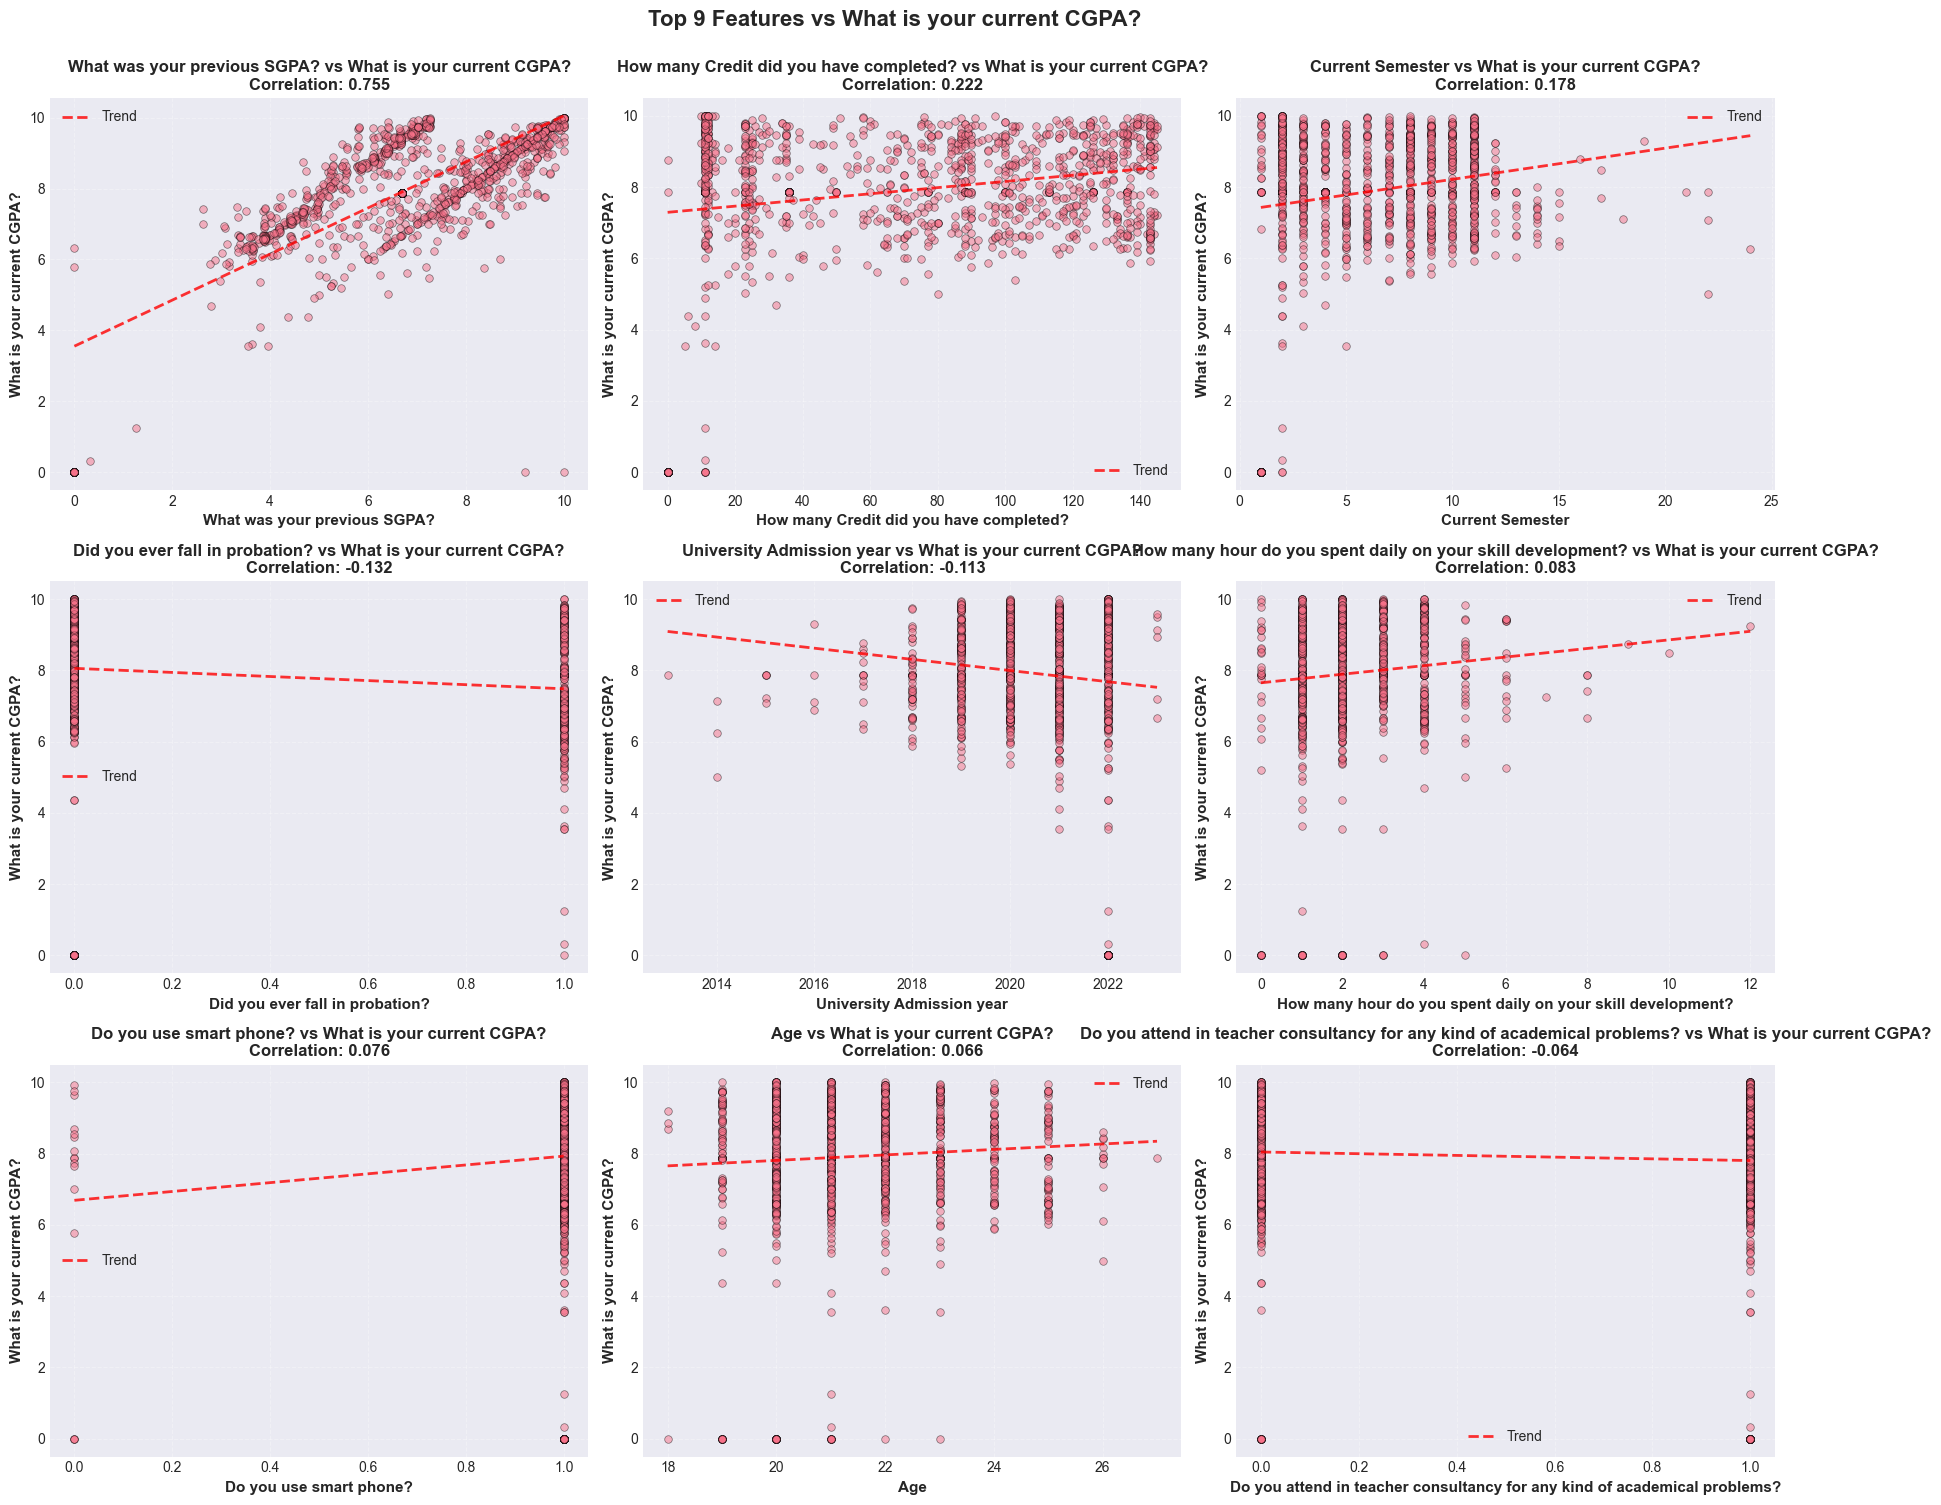

✅ Scatter Plots Created


In [58]:
# Get top 9 numerical features most correlated with CGPA
top_9_numerical = correlations_all[1:10].index.tolist()  # Exclude CGPA itself

# Create 3x3 grid of scatter plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(top_9_numerical):
    # Scatter plot
    axes[idx].scatter(df_encoded[feature], df_encoded[TARGET_COLUMN], 
                     alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(df_encoded[feature], df_encoded[TARGET_COLUMN], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_encoded[feature].min(), df_encoded[feature].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend')
    
    # Calculate correlation
    corr = df_encoded[[feature, TARGET_COLUMN]].corr().iloc[0, 1]
    
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(TARGET_COLUMN, fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature} vs {TARGET_COLUMN}\nCorrelation: {corr:.3f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3, linestyle='--')
    axes[idx].legend(loc='best')

plt.suptitle(f'Top 9 Features vs {TARGET_COLUMN}', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Scatter Plots Created")

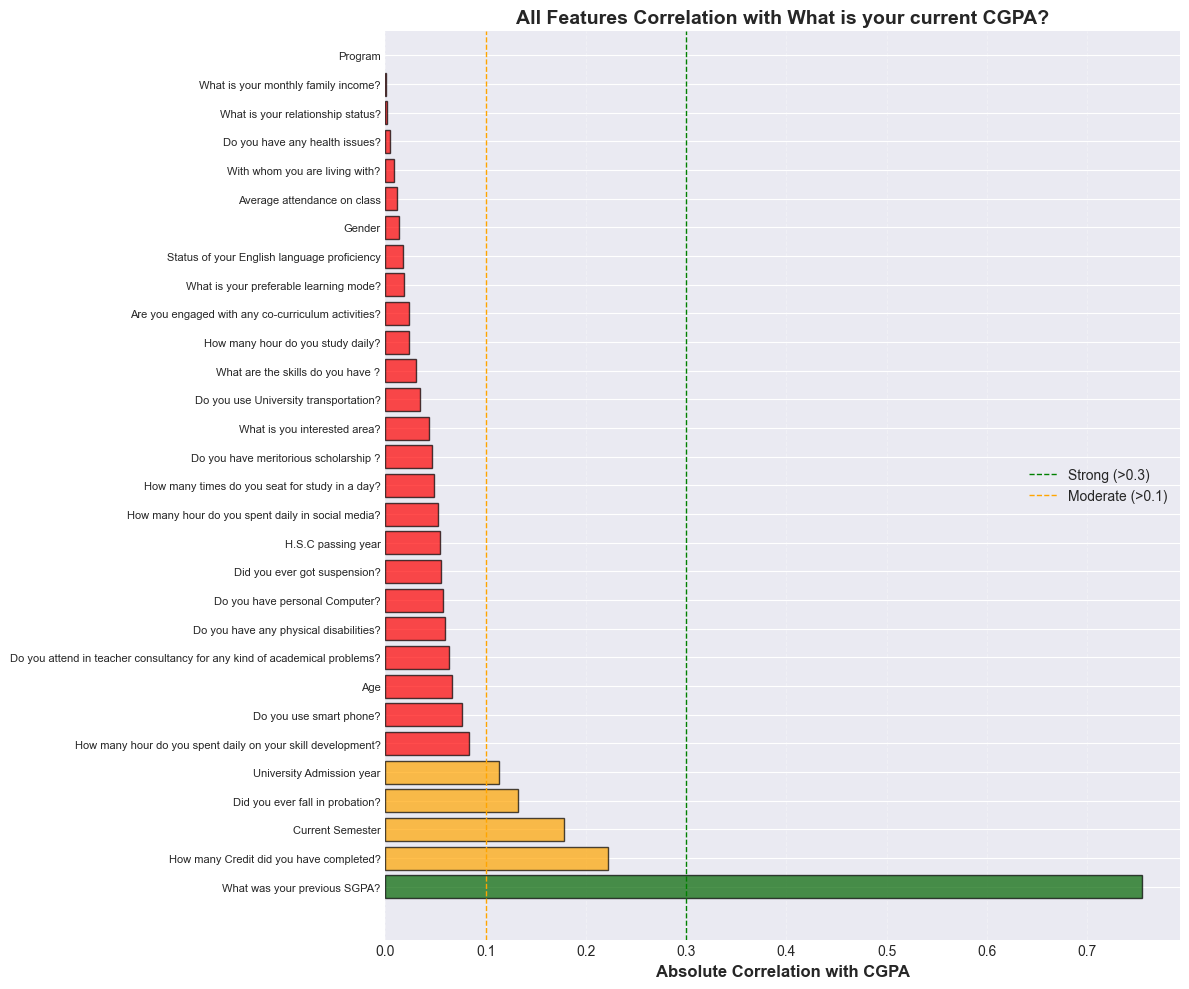

✅ All Features Correlation Chart Created


In [59]:
# Show all features correlation
plt.figure(figsize=(12, 10))
all_correlations = correlations_all[1:]  # Exclude CGPA itself

colors_all = ['darkgreen' if x > 0.3 else 'orange' if x > 0.1 else 'red' for x in all_correlations.values]
plt.barh(range(len(all_correlations)), all_correlations.values, color=colors_all, alpha=0.7, edgecolor='black')
plt.yticks(range(len(all_correlations)), all_correlations.index, fontsize=8)
plt.xlabel('Absolute Correlation with CGPA', fontsize=12, fontweight='bold')
plt.title(f'All Features Correlation with {TARGET_COLUMN}', fontsize=14, fontweight='bold')
plt.axvline(x=0.3, color='green', linestyle='--', linewidth=1, label='Strong (>0.3)')
plt.axvline(x=0.1, color='orange', linestyle='--', linewidth=1, label='Moderate (>0.1)')
plt.legend()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("✅ All Features Correlation Chart Created")

Top 15 Features Correlated with CGPA:
What is your current CGPA?                                     1.000000
What was your previous SGPA?                                   0.755055
How many Credit did you have completed?                        0.222052
Current Semester                                               0.177826
How many hour do you spent daily on your skill development?    0.083224
Do you use smart phone?                                        0.076060
Age                                                            0.066038
Do you have personal Computer?                                 0.057942
How many times do you seat for study in a day?                 0.048802
Do you have meritorious scholarship ?                          0.046886
What are the skills do you have ?                              0.030554
How many hour do you study daily?                              0.023690
Status of your English language proficiency                    0.017508
Gender                    

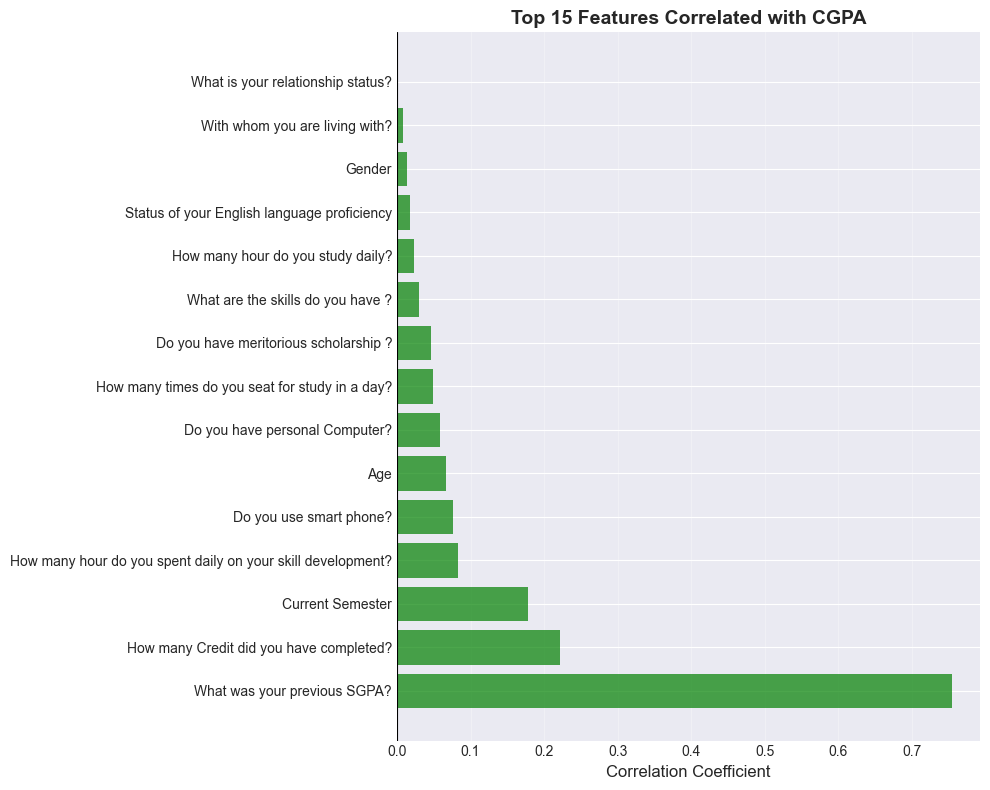

In [60]:
# Calculate correlation with CGPA
correlations = df_encoded.corr()[cgpa_col[1]].sort_values(ascending=False)

print("Top 15 Features Correlated with CGPA:")
print(correlations.head(16))  # 16 to include CGPA itself

# Plot top correlations
plt.figure(figsize=(10, 8))
top_features = correlations.head(16)[1:]  # Exclude CGPA itself
colors = ['green' if x > 0 else 'red' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index, fontsize=10)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Top 15 Features Correlated with CGPA', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Top 15 Most Important Features:
                                              Feature  Importance
26                       What was your previous SGPA?    0.776955
28            How many Credit did you have completed?    0.071577
29                What is your monthly family income?    0.025739
15                        Average attendance on class    0.014984
19                  What are the skills do you have ?    0.014115
0                           University Admission year    0.012175
5                                    Current Semester    0.010970
13  How many hour do you spent daily in social media?    0.010716
20  How many hour do you spent daily on your skill...    0.009777
3                                  H.S.C passing year    0.007817
16                    Did you ever fall in probation?    0.006866
21                       What is you interested area?    0.006557
2                                                 Age    0.005741
9      How many times do you seat for study 

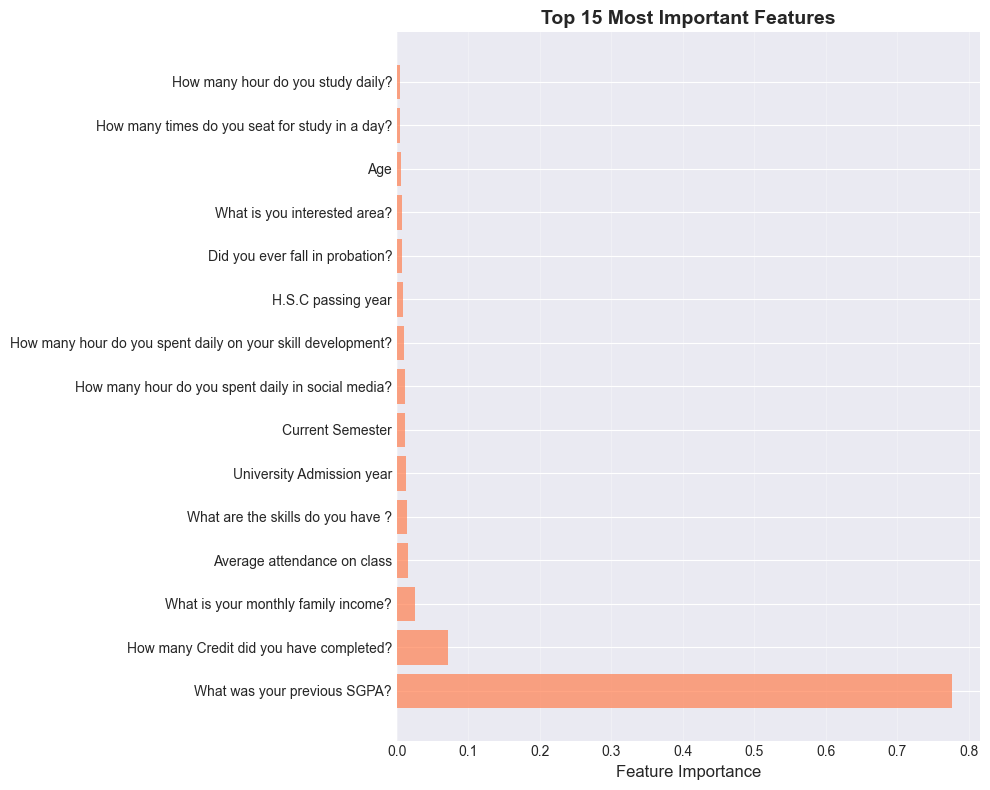


✅ Identified 10 most important features for user input


In [61]:
# Prepare data for feature importance
X_temp = df_encoded.drop([cgpa_col[1]], axis=1)
y_temp = df_encoded[cgpa_col[1]]

# Train Random Forest to get feature importance
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_temp, y_temp)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values, color='coral', alpha=0.7)
plt.yticks(range(len(top_15)), top_15['Feature'].values, fontsize=10)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Save important features for later use
IMPORTANT_FEATURES = feature_importance.head(10)['Feature'].tolist()
print(f"\n✅ Identified {len(IMPORTANT_FEATURES)} most important features for user input")

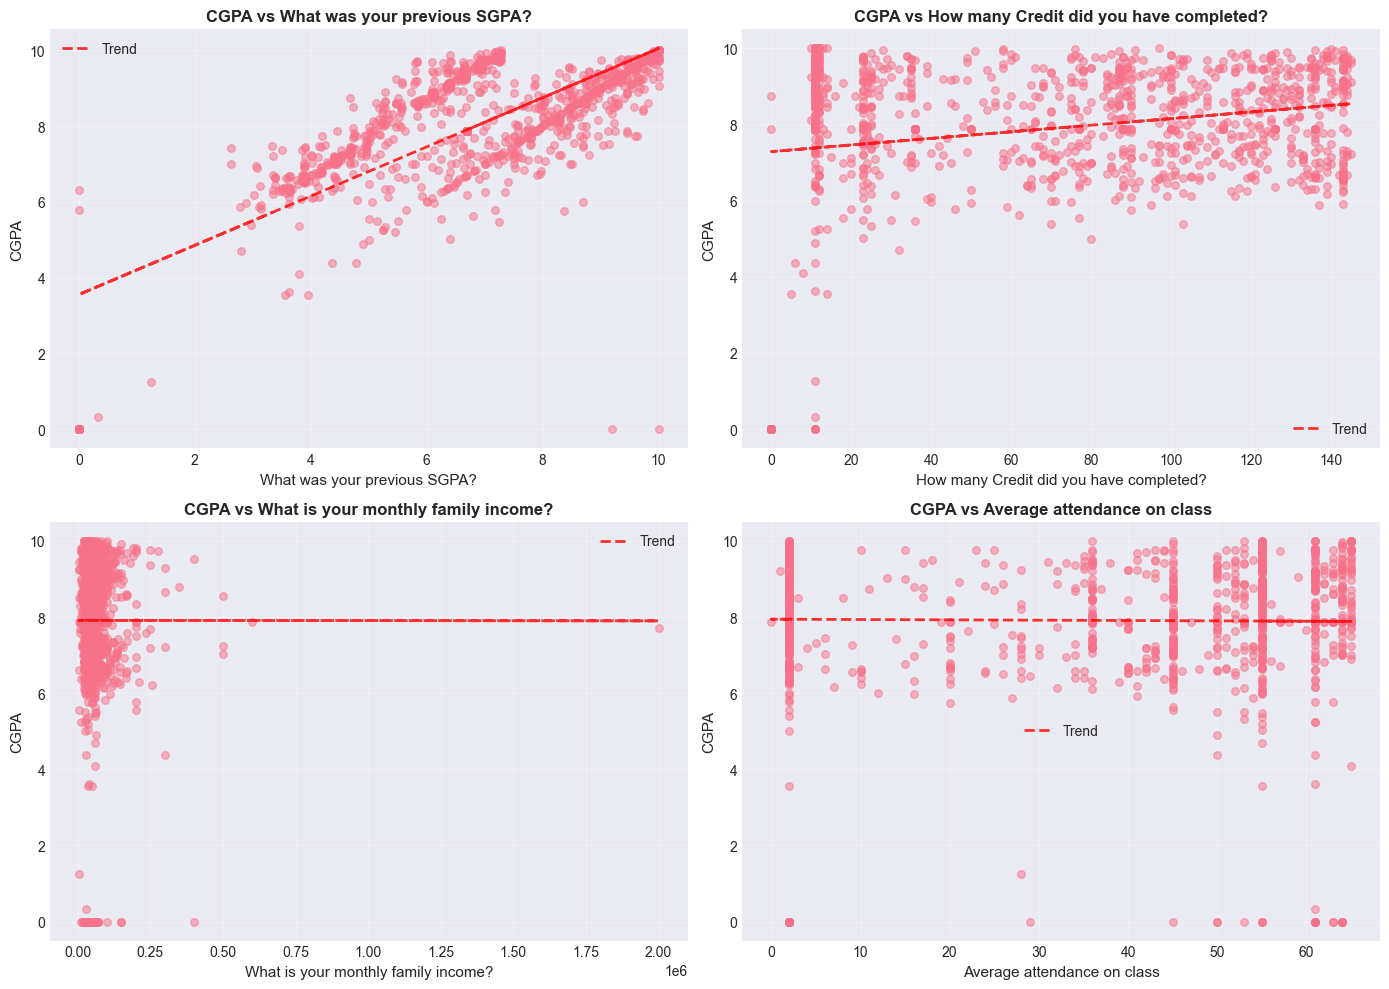

In [62]:
# Get top 4 numerical features for visualization
top_numerical = []
for feat in IMPORTANT_FEATURES:
    if df_encoded[feat].dtype in ['float64', 'int64']:
        top_numerical.append(feat)
        if len(top_numerical) == 4:
            break

# Create scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_numerical):
    axes[idx].scatter(df_encoded[feature], df_encoded[cgpa_col[1]], alpha=0.5, s=30)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('CGPA', fontsize=11)
    axes[idx].set_title(f'CGPA vs {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_encoded[feature], df_encoded[cgpa_col[1]], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_encoded[feature], p(df_encoded[feature]), 
                   "r--", alpha=0.8, linewidth=2, label='Trend')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [63]:
cgpa_col[1]

'What is your current CGPA?'

In [64]:
# Prepare features and target
X = df_encoded.drop([cgpa_col[1]], axis=1)
y = df_encoded[cgpa_col[1]]

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Data Split Complete!")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Testing samples: {X_test.shape[0]}")

# Feature Scaling (for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save median values for user input imputation
median_values = X_train.median().to_dict()

print(f" Feature scaling complete!")
print(f" Saved median values for {len(median_values)} features")

Feature Matrix Shape: (1194, 30)
Target Vector Shape: (1194,)

 Data Split Complete!
   Training samples: 955
   Testing samples: 239
 Feature scaling complete!
 Saved median values for 30 features


In [65]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 30 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   University Admission year                                                  1194 non-null   int64  
 1   Gender                                                                     1194 non-null   int64  
 2   Age                                                                        1194 non-null   int64  
 3   H.S.C passing year                                                         1194 non-null   int64  
 4   Program                                                                    1194 non-null   int64  
 5   Current Semester                                                           1194 non-null   int64  
 6   Do you have meritorious scholarship ?                   

In [66]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Print results
    print(f"\n{model_name}")
    print("_"*70)
    print(f"{'Metric':<15} {'Train':<20} {'Test':<20}")
    print("_"*70)
    print(f"{'RMSE':<15} {train_rmse:<20.4f} {test_rmse:<20.4f}")
    print(f"{'MAE':<15} {train_mae:<20.4f} {test_mae:<20.4f}")
    print(f"{'Accuracy':<15} {train_r2 * 100:<20.4f} {test_r2*100:<20.4f}")
    
    return {
        'Model': model_name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_R2': train_r2,
        'Test_R2': test_r2
    }


print("Evaluation Function for performance matrix")

Evaluation Function for performance matrix


In [67]:
# Store results
results = []
models = {}

In [68]:
print("\n Training Linear Regression (Baseline)")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
result = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression')
results.append(result)
models['Linear Regression'] = lr


 Training Linear Regression (Baseline)

Linear Regression
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.9588               0.8215              
MAE             0.6540               0.6129              
Accuracy        74.3662              78.9805             


In [69]:
print("\n Training Ridge Regression (Regularized)...")
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
result = evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression')
results.append(result)
models['Ridge Regression'] = ridge


 Training Ridge Regression (Regularized)...

Ridge Regression
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.9588               0.8214              
MAE             0.6540               0.6128              
Accuracy        74.3659              78.9885             


In [70]:
print("\n Training Random Forest (Tree-based Ensemble)...")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
result = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest')
results.append(result)
models['Random Forest'] = rf


 Training Random Forest (Tree-based Ensemble)...

Random Forest
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.4212               0.5866              
MAE             0.1986               0.3770              
Accuracy        95.0524              89.2842             


In [71]:
print("\n Training XGBoost (Advanced Boosting)...")
xgboost = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgboost.fit(X_train, y_train)
result = evaluate_model(xgboost, X_train, X_test, y_train, y_test, 'XGBoost')
results.append(result)
models['XGBoost'] = xgboost


 Training XGBoost (Advanced Boosting)...

XGBoost
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.0584               0.5846              
MAE             0.0415               0.4163              
Accuracy        99.9050              89.3564             


In [72]:
print("\n Training LightGBM (Fast and Efficient)...")
lgbm = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
result = evaluate_model(lgbm, X_train, X_test, y_train, y_test, 'LightGBM')
results.append(result)
models['LightGBM'] = lgbm


 Training LightGBM (Fast and Efficient)...

LightGBM
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.3373               0.6292              
MAE             0.2022               0.4464              
Accuracy        96.8283              87.6710             


In [73]:
print("\n Training SVM (SVR Model)...")

from sklearn.svm import SVR

svm_model = SVR(
    kernel='rbf',      # RBF works best in most regression cases
    C=100,             # Regularization strength
    gamma='scale',     # Default kernel coefficient
    epsilon=0.1,       # Epsilon parameter for SVR
    cache_size=1000    # Increase cache for faster training
)

# ⚠️ IMPORTANT: SVR requires scaled data!
svm_model.fit(X_train_scaled, y_train)

result = evaluate_model(svm_model, X_train_scaled, X_test_scaled, y_train, y_test, "SVM")
results.append(result)
models["SVM"] = svm_model

print("\n SVM trained successfully!")


 Training SVM (SVR Model)...

SVM
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.1387               0.8998              
MAE             0.0982               0.6709              
Accuracy        99.4636              74.7861             

 SVM trained successfully!


In [74]:
results_df = pd.DataFrame(results)

print("\n" + "_"*80)
print("MODEL COMPARISON SUMMARY")
print("_"*80)
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['Test_R2'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'Test_R2']
best_rmse = results_df.loc[best_idx, 'Test_RMSE']
best_mae = results_df.loc[best_idx, 'Test_MAE']

print(f"\n Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"   MAE: {best_mae:.4f}")


________________________________________________________________________________
MODEL COMPARISON SUMMARY
________________________________________________________________________________
            Model  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_R2  Test_R2
Linear Regression    0.958806   0.821530   0.653958  0.612906  0.743662 0.789805
 Ridge Regression    0.958811   0.821373   0.654043  0.612831  0.743659 0.789885
    Random Forest    0.421232   0.586575   0.198575  0.376950  0.950524 0.892842
          XGBoost    0.058373   0.584595   0.041478  0.416296  0.999050 0.893564
         LightGBM    0.337264   0.629180   0.202167  0.446437  0.968283 0.876710
              SVM    0.138697   0.899771   0.098213  0.670865  0.994636 0.747861

 Best Model: XGBoost
   R² Score: 0.8936
   RMSE: 0.5846
   MAE: 0.4163


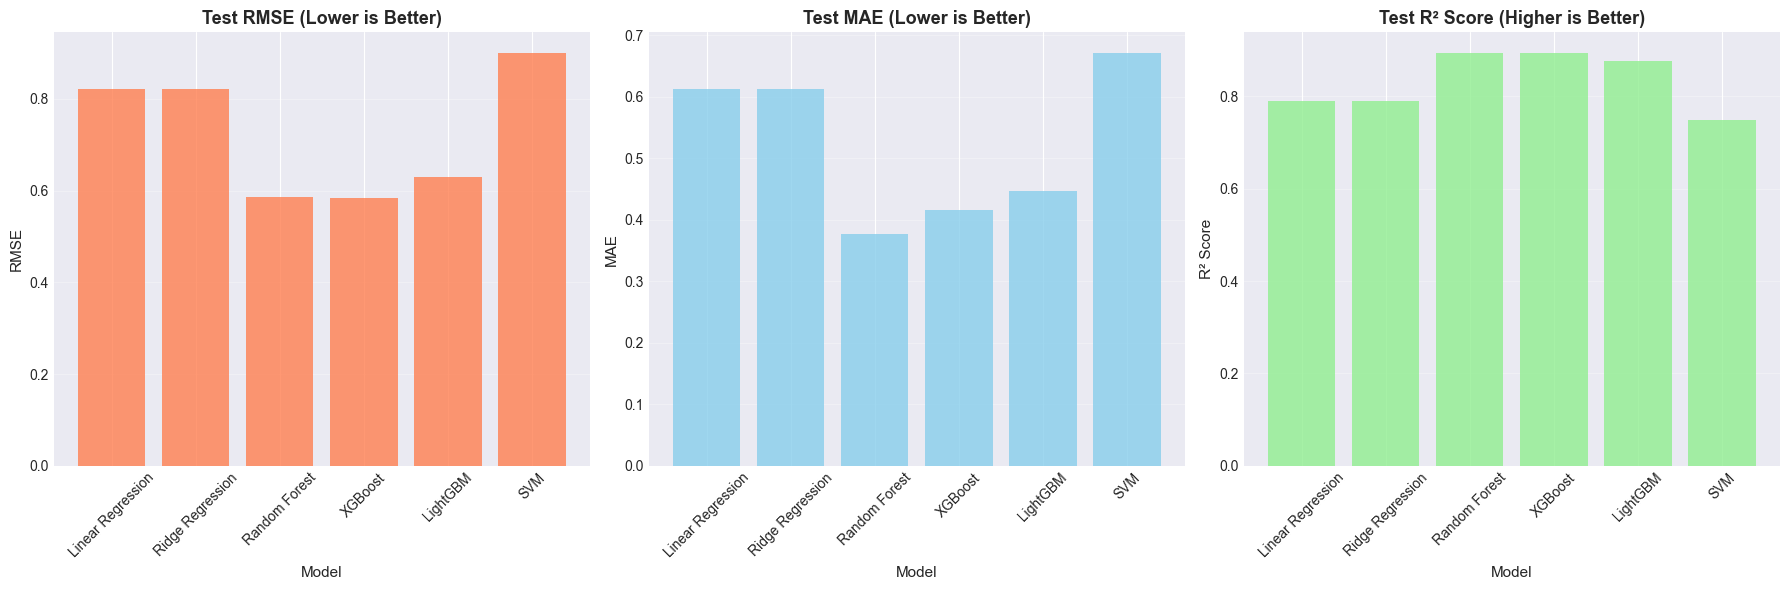

In [75]:
# Model Visualisation 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Comparison
axes[0].bar(results_df['Model'], results_df['Test_RMSE'], color='coral', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Test RMSE (Lower is Better)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# MAE Comparison
axes[1].bar(results_df['Model'], results_df['Test_MAE'], color='skyblue', alpha=0.8)
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Test MAE (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# R² Comparison
axes[2].bar(results_df['Model'], results_df['Test_R2'], color='lightgreen', alpha=0.8)
axes[2].set_xlabel('Model', fontsize=11)
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_title('Test R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

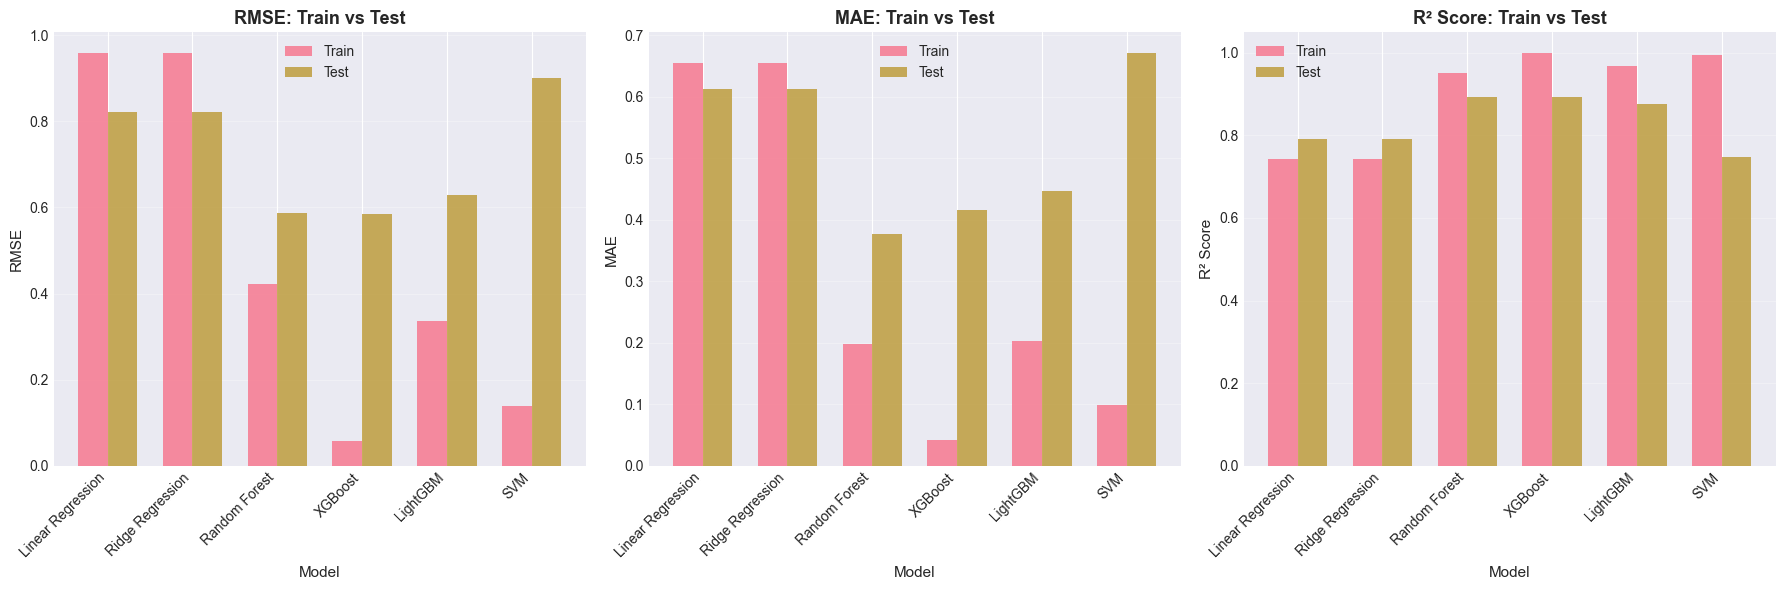

In [76]:
# Create comparison plot for train vs test


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(len(results_df))
width = 0.35

# RMSE - Train vs Test
axes[0].bar(x - width/2, results_df['Train_RMSE'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, results_df['Test_RMSE'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('RMSE: Train vs Test', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# MAE - Train vs Test
axes[1].bar(x - width/2, results_df['Train_MAE'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, results_df['Test_MAE'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('MAE: Train vs Test', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# R² - Train vs Test
axes[2].bar(x - width/2, results_df['Train_R2'], width, label='Train', alpha=0.8)
axes[2].bar(x + width/2, results_df['Test_R2'], width, label='Test', alpha=0.8)
axes[2].set_xlabel('Model', fontsize=11)
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_title('R² Score: Train vs Test', fontsize=13, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
# Ensemble Model


print("CREATING ENSEMBLE MODELS")


from sklearn.ensemble import VotingRegressor, StackingRegressor

print("\n📊 Base Models Available for Ensemble:")
for i, (name, model) in enumerate(models.items(), 1):
    print(f"   {i}. {name}")

CREATING ENSEMBLE MODELS

📊 Base Models Available for Ensemble:
   1. Linear Regression
   2. Ridge Regression
   3. Random Forest
   4. XGBoost
   5. LightGBM
   6. SVM


In [78]:
print("\n" + "-"*80)
print("METHOD 1: SIMPLE VOTING ENSEMBLE")
print("-"*80)

# Create voting ensemble with equal weights
voting_estimators = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=1.0, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5, 
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, 
                             subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, 
                               num_leaves=31, random_state=42, n_jobs=-1, verbose=-1))
]

voting_ensemble = VotingRegressor(estimators=voting_estimators, n_jobs=-1)

print("\n🔄 Training Simple Voting Ensemble...")
voting_ensemble.fit(X_train, y_train)

result = evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test, 'Voting Ensemble')
results.append(result)
models['Voting Ensemble'] = voting_ensemble

print(" Simple Voting Ensemble Complete!")


--------------------------------------------------------------------------------
METHOD 1: SIMPLE VOTING ENSEMBLE
--------------------------------------------------------------------------------

🔄 Training Simple Voting Ensemble...

Voting Ensemble
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.4988               0.5637              
MAE             0.3188               0.4214              
Accuracy        93.0617              90.1044             
 Simple Voting Ensemble Complete!


In [79]:
print("\n" + "-"*80)
print("METHOD 2: WEIGHTED VOTING ENSEMBLE")
print("-"*80)

# Calculate weights based on Test R² scores
results_df_temp = pd.DataFrame(results)
base_models_list = ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost', 'LightGBM']

print("\n📊 Calculating Weights Based on Test R² Performance:")
model_weights = []

for model_name in base_models_list:
    if model_name in results_df_temp['Model'].values:
        r2 = results_df_temp[results_df_temp['Model'] == model_name]['Test_R2'].values[0]
        weight = max(r2, 0.01)  # Ensure non-negative
        model_weights.append(weight)
        print(f"   {model_name:<25s}: R² = {r2:.4f} → Weight = {weight:.4f}")

# Normalize weights
model_weights = np.array(model_weights)
model_weights = model_weights / model_weights.sum()

print("\n📊 Normalized Weights:")
for name, weight in zip(base_models_list, model_weights):
    print(f"   {name:<25s}: {weight:.4f} ({weight*100:.2f}%)")

# Create weighted voting ensemble
weighted_voting = VotingRegressor(
    estimators=voting_estimators,
    weights=model_weights,
    n_jobs=-1
)

print("\n🔄 Training Weighted Voting Ensemble...")
weighted_voting.fit(X_train, y_train)

result = evaluate_model(weighted_voting, X_train, X_test, y_train, y_test, 'Weighted Voting Ensemble')
results.append(result)
models['Weighted Voting Ensemble'] = weighted_voting



--------------------------------------------------------------------------------
METHOD 2: WEIGHTED VOTING ENSEMBLE
--------------------------------------------------------------------------------

📊 Calculating Weights Based on Test R² Performance:
   Linear Regression        : R² = 0.7898 → Weight = 0.7898
   Ridge Regression         : R² = 0.7899 → Weight = 0.7899
   Random Forest            : R² = 0.8928 → Weight = 0.8928
   XGBoost                  : R² = 0.8936 → Weight = 0.8936
   LightGBM                 : R² = 0.8767 → Weight = 0.8767

📊 Normalized Weights:
   Linear Regression        : 0.1862 (18.62%)
   Ridge Regression         : 0.1862 (18.62%)
   Random Forest            : 0.2104 (21.04%)
   XGBoost                  : 0.2106 (21.06%)
   LightGBM                 : 0.2066 (20.66%)

🔄 Training Weighted Voting Ensemble...

Weighted Voting Ensemble
______________________________________________________________________
Metric          Train                Test                
_

In [80]:
# Stacking with ridge as meta model

print("\n" + "-"*80)
print("METHOD 3: STACKING ENSEMBLE")
print("-"*80)

# Base models for stacking
stacking_base_models = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=1.0, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, 
                               random_state=42, n_jobs=-1, verbose=-1))
]

# Meta-model
meta_model = Ridge(alpha=1.0, random_state=42)

# Create stacking ensemble
stacking_ensemble = StackingRegressor(
    estimators=stacking_base_models,
    final_estimator=meta_model,
    cv=5,  # 5-fold cross-validation
    n_jobs=-1
)

print("\n🔄 Training Stacking Ensemble with 5-Fold CV...")
print("   (This may take a moment...)")
stacking_ensemble.fit(X_train, y_train)

result = evaluate_model(stacking_ensemble, X_train, X_test, y_train, y_test, 'Stacking Ensemble')
results.append(result)
models['Stacking Ensemble'] = stacking_ensemble

print("✅ Stacking Ensemble Complete!")


--------------------------------------------------------------------------------
METHOD 3: STACKING ENSEMBLE
--------------------------------------------------------------------------------

🔄 Training Stacking Ensemble with 5-Fold CV...
   (This may take a moment...)

Stacking Ensemble
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.3804               0.5391              
MAE             0.2414               0.3740              
Accuracy        95.9647              90.9489             
✅ Stacking Ensemble Complete!


In [81]:
# Stacking with XG-Boost as meta model

print("\n" + "-"*80)
print("METHOD 4: STACKING WITH XGBOOST META-MODEL")
print("-"*80)

# XGBoost as meta-model
meta_xgb = xgb.XGBRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

stacking_xgb = StackingRegressor(
    estimators=stacking_base_models,
    final_estimator=meta_xgb,
    cv=5,
    n_jobs=-1
)

print("\n🔄 Training Stacking Ensemble (XGBoost Meta-Model)...")
stacking_xgb.fit(X_train, y_train)

result = evaluate_model(stacking_xgb, X_train, X_test, y_train, y_test, 'Stacking-XGBoost')
results.append(result)
models['Stacking-XGBoost'] = stacking_xgb

print("✅ Stacking with XGBoost Meta-Model Complete!")


--------------------------------------------------------------------------------
METHOD 4: STACKING WITH XGBOOST META-MODEL
--------------------------------------------------------------------------------

🔄 Training Stacking Ensemble (XGBoost Meta-Model)...

Stacking-XGBoost
______________________________________________________________________
Metric          Train                Test                
______________________________________________________________________
RMSE            0.4714               0.6909              
MAE             0.2855               0.4358              
Accuracy        93.8025              85.1349             
✅ Stacking with XGBoost Meta-Model Complete!


In [82]:
# Ensemble Comparison

print("\n" + "="*80)
print("ENSEMBLE MODEL COMPARISON")
print("="*80)

# Update results dataframe
results_df = pd.DataFrame(results)

# Show only ensemble models
ensemble_models = ['Voting Ensemble', 'Weighted Voting Ensemble', 'Stacking Ensemble', 'Stacking-XGBoost']
ensemble_results = results_df[results_df['Model'].isin(ensemble_models)]

print("\n📊 Ensemble Models Performance:")
print(ensemble_results.to_string(index=False))

# Compare with base models
print("\n📊 ALL Models Performance (Base + Ensemble):")
print(results_df.to_string(index=False))

# Find overall best model
best_idx = results_df['Test_R2'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'Test_R2']
best_rmse = results_df.loc[best_idx, 'Test_RMSE']
best_mae = results_df.loc[best_idx, 'Test_MAE']

print(f"\n{'='*80}")
print(f"🏆 OVERALL BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"   R² Score:  {best_r2:.4f}")
print(f"   RMSE:      {best_rmse:.4f}")
print(f"   MAE:       {best_mae:.4f}")


ENSEMBLE MODEL COMPARISON

📊 Ensemble Models Performance:
                   Model  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_R2  Test_R2
         Voting Ensemble    0.498826   0.563681   0.318821  0.421432  0.930617 0.901044
Weighted Voting Ensemble    0.478632   0.558072   0.303930  0.415985  0.936121 0.903003
       Stacking Ensemble    0.380417   0.539091   0.241358  0.374029  0.959647 0.909489
        Stacking-XGBoost    0.471447   0.690868   0.285463  0.435763  0.938025 0.851349

📊 ALL Models Performance (Base + Ensemble):
                   Model  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_R2  Test_R2
       Linear Regression    0.958806   0.821530   0.653958  0.612906  0.743662 0.789805
        Ridge Regression    0.958811   0.821373   0.654043  0.612831  0.743659 0.789885
           Random Forest    0.421232   0.586575   0.198575  0.376950  0.950524 0.892842
                 XGBoost    0.058373   0.584595   0.041478  0.416296  0.999050 0.893564
                


📊 Creating Ensemble Comparison Visualizations...


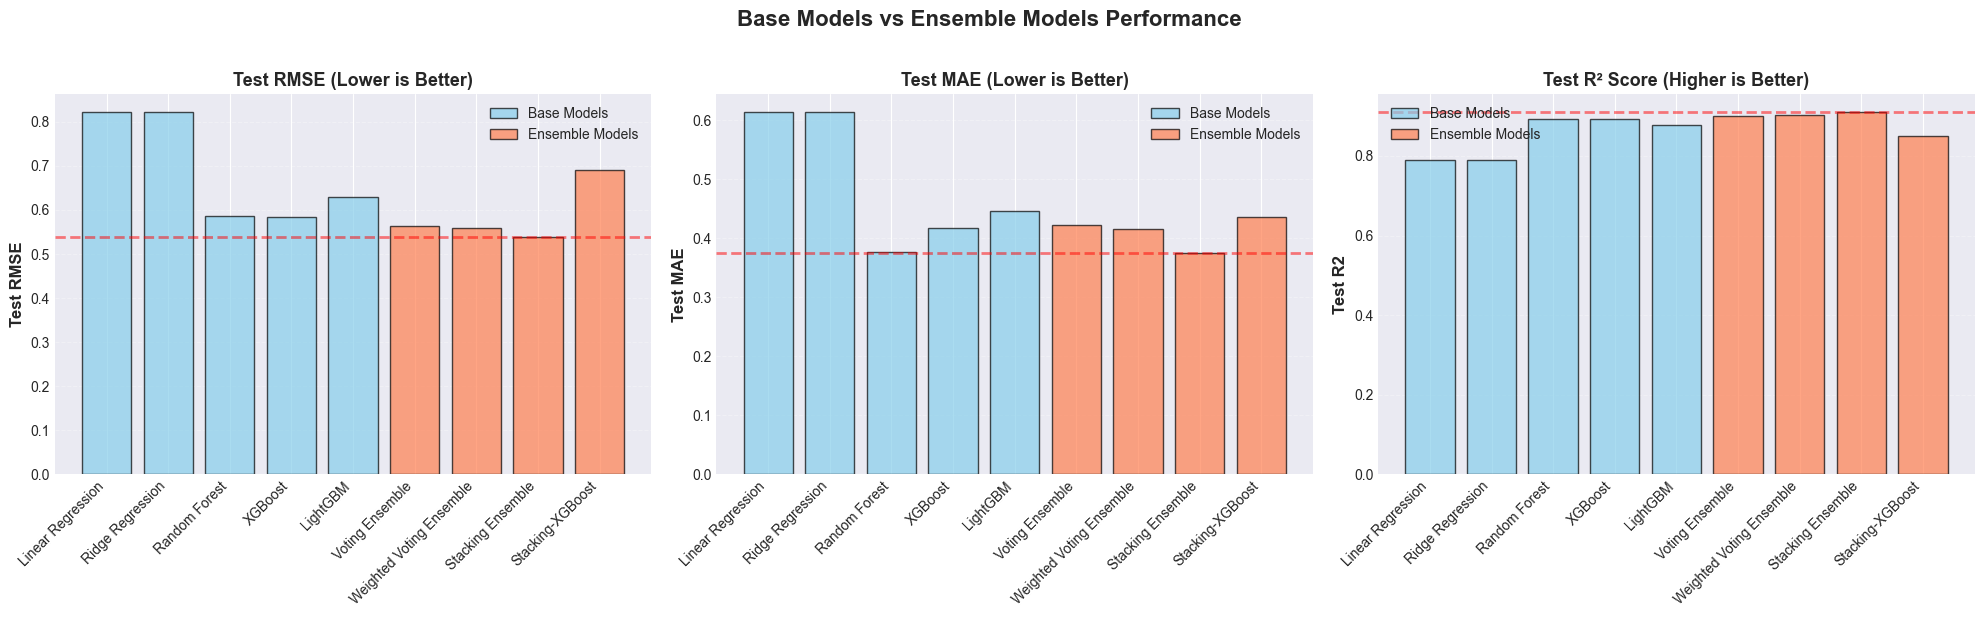

✅ Ensemble comparison visualization created!


In [83]:
print("\n📊 Creating Ensemble Comparison Visualizations...")

# Separate base and ensemble models
base_model_names = ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost', 'LightGBM']
base_results = results_df[results_df['Model'].isin(base_model_names)]
ensemble_results = results_df[results_df['Model'].isin(ensemble_models)]

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['Test_RMSE', 'Test_MAE', 'Test_R2']
titles = ['Test RMSE (Lower is Better)', 'Test MAE (Lower is Better)', 'Test R² Score (Higher is Better)']
colors_base = 'skyblue'
colors_ensemble = 'coral'

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    # Base models
    axes[idx].bar(base_results['Model'], base_results[metric], 
                  alpha=0.7, label='Base Models', color=colors_base, edgecolor='black')
    
    # Ensemble models
    x_offset = len(base_results)
    axes[idx].bar(range(x_offset, x_offset + len(ensemble_results)), 
                  ensemble_results[metric], 
                  alpha=0.7, label='Ensemble Models', color=colors_ensemble, edgecolor='black')
    
    # Formatting
    all_labels = list(base_results['Model']) + list(ensemble_results['Model'])
    axes[idx].set_xticks(range(len(all_labels)))
    axes[idx].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=10)
    axes[idx].set_ylabel(metric.replace('_', ' '), fontsize=12, fontweight='bold')
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Highlight best model
    best_value = results_df[metric].max() if metric == 'Test_R2' else results_df[metric].min()
    axes[idx].axhline(y=best_value, color='red', linestyle='--', linewidth=2, alpha=0.5)

plt.suptitle('Base Models vs Ensemble Models Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✅ Ensemble comparison visualization created!")

In [84]:
print("\n" + "_"*80)
print("ENSEMBLE PERFORMANCE IMPROVEMENT ANALYSIS")
print("_"*80)

# Get best base model performance
best_base_r2 = base_results['Test_R2'].max()
best_base_model = base_results.loc[base_results['Test_R2'].idxmax(), 'Model']

print(f"\n📊 Best Base Model: {best_base_model}")
print(f"   R² Score: {best_base_r2:.4f}")

print(f"\n📊 Ensemble Models Improvement:")
for idx, row in ensemble_results.iterrows():
    improvement = ((row['Test_R2'] - best_base_r2) / best_base_r2) * 100
    symbol = "✅" if improvement > 0 else "⚠️"
    print(f"\n{symbol} {row['Model']}:")
    print(f"   R² Score: {row['Test_R2']:.4f}")
    print(f"   Improvement: {improvement:+.2f}%")
    print(f"   RMSE: {row['Test_RMSE']:.4f}")
    print(f"   MAE: {row['Test_MAE']:.4f}")


________________________________________________________________________________
ENSEMBLE PERFORMANCE IMPROVEMENT ANALYSIS
________________________________________________________________________________

📊 Best Base Model: XGBoost
   R² Score: 0.8936

📊 Ensemble Models Improvement:

✅ Voting Ensemble:
   R² Score: 0.9010
   Improvement: +0.84%
   RMSE: 0.5637
   MAE: 0.4214

✅ Weighted Voting Ensemble:
   R² Score: 0.9030
   Improvement: +1.06%
   RMSE: 0.5581
   MAE: 0.4160

✅ Stacking Ensemble:
   R² Score: 0.9095
   Improvement: +1.78%
   RMSE: 0.5391
   MAE: 0.3740

⚠️ Stacking-XGBoost:
   R² Score: 0.8513
   Improvement: -4.72%
   RMSE: 0.6909
   MAE: 0.4358


In [85]:
## Quick Test Without Interactive Input

def quick_predict_test():
    """
    Quick test function with sample data
    """
    
    print("\n" + "="*80)
    print("🧪 QUICK TEST - STACKING ENSEMBLE")
    print("="*80)
    
    # Sample data (adjust to your features)
    test_data = {}
    
    # Use median values for top 5 features
    for i, feat in enumerate(IMPORTANT_FEATURES[:5], 1):
        if df_encoded[feat].dtype in ['int64', 'float64']:
            test_data[feat] = df_encoded[feat].median()
        else:
            test_data[feat] = df_encoded[feat].mode()[0]
    
    print("\n📋 Test Data:")
    for key, value in test_data.items():
        print(f"   • {key:<35s}: {value}")
    
    # Predict
    full_input = pd.DataFrame([median_values])
    for key, value in test_data.items():
        if key in full_input.columns:
            full_input[key] = value
    
    full_input = full_input[X_train.columns]
    
    stacking_model = models['Stacking Ensemble']
    prediction = stacking_model.predict(full_input)[0]
    prediction = np.clip(prediction, 0, 10)
    
    print(f"\n🎓 Predicted CGPA: {prediction:.2f} / 10.0")
    print("="*80)
    
    return prediction

# Uncomment to test:
quick_predict_test()


🧪 QUICK TEST - STACKING ENSEMBLE

📋 Test Data:
   • What was your previous SGPA?       : 6.7
   • How many Credit did you have completed?: 78.0
   • What is your monthly family income?: 50000.0
   • Average attendance on class        : 45.0
   • What are the skills do you have ?  : 39.0

🎓 Predicted CGPA: 7.96 / 10.0


np.float64(7.958558479311319)

In [86]:
import pickle
import os
# Create models directory
os.makedirs('models', exist_ok=True)

# Save best model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(models[best_model_name], f)

# Save all models
with open('models/all_models.pkl', 'wb') as f:
    pickle.dump(models, f)

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save median values
with open('models/median_values.pkl', 'wb') as f:
    pickle.dump(median_values, f)

# Save feature names
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# Save important features
with open('models/important_features.pkl', 'wb') as f:
    pickle.dump(IMPORTANT_FEATURES, f)

# Save label encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save results
results_df.to_csv('models/model_results.csv', index=False)

print("✅ All models and artifacts saved successfully!")
print("\nSaved files in 'models/' directory:")
print("  📁 best_model.pkl")
print("  📁 all_models.pkl")
print("  📁 scaler.pkl")
print("  📁 median_values.pkl")
print("  📁 feature_names.pkl")
print("  📁 important_features.pkl")
print("  📁 label_encoders.pkl")
print("  📁 model_results.csv")


✅ All models and artifacts saved successfully!

Saved files in 'models/' directory:
  📁 best_model.pkl
  📁 all_models.pkl
  📁 scaler.pkl
  📁 median_values.pkl
  📁 feature_names.pkl
  📁 important_features.pkl
  📁 label_encoders.pkl
  📁 model_results.csv
